<a href="https://colab.research.google.com/github/SubodhWalondre-1/Pattern-Recognition-Lab/blob/main/practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 1.jpg to 1.jpg
Original Image Shape: (949, 1024, 3)

Estimated Product Dimensions
-----------------------------
Width : 676 pixels
Height: 676 pixels


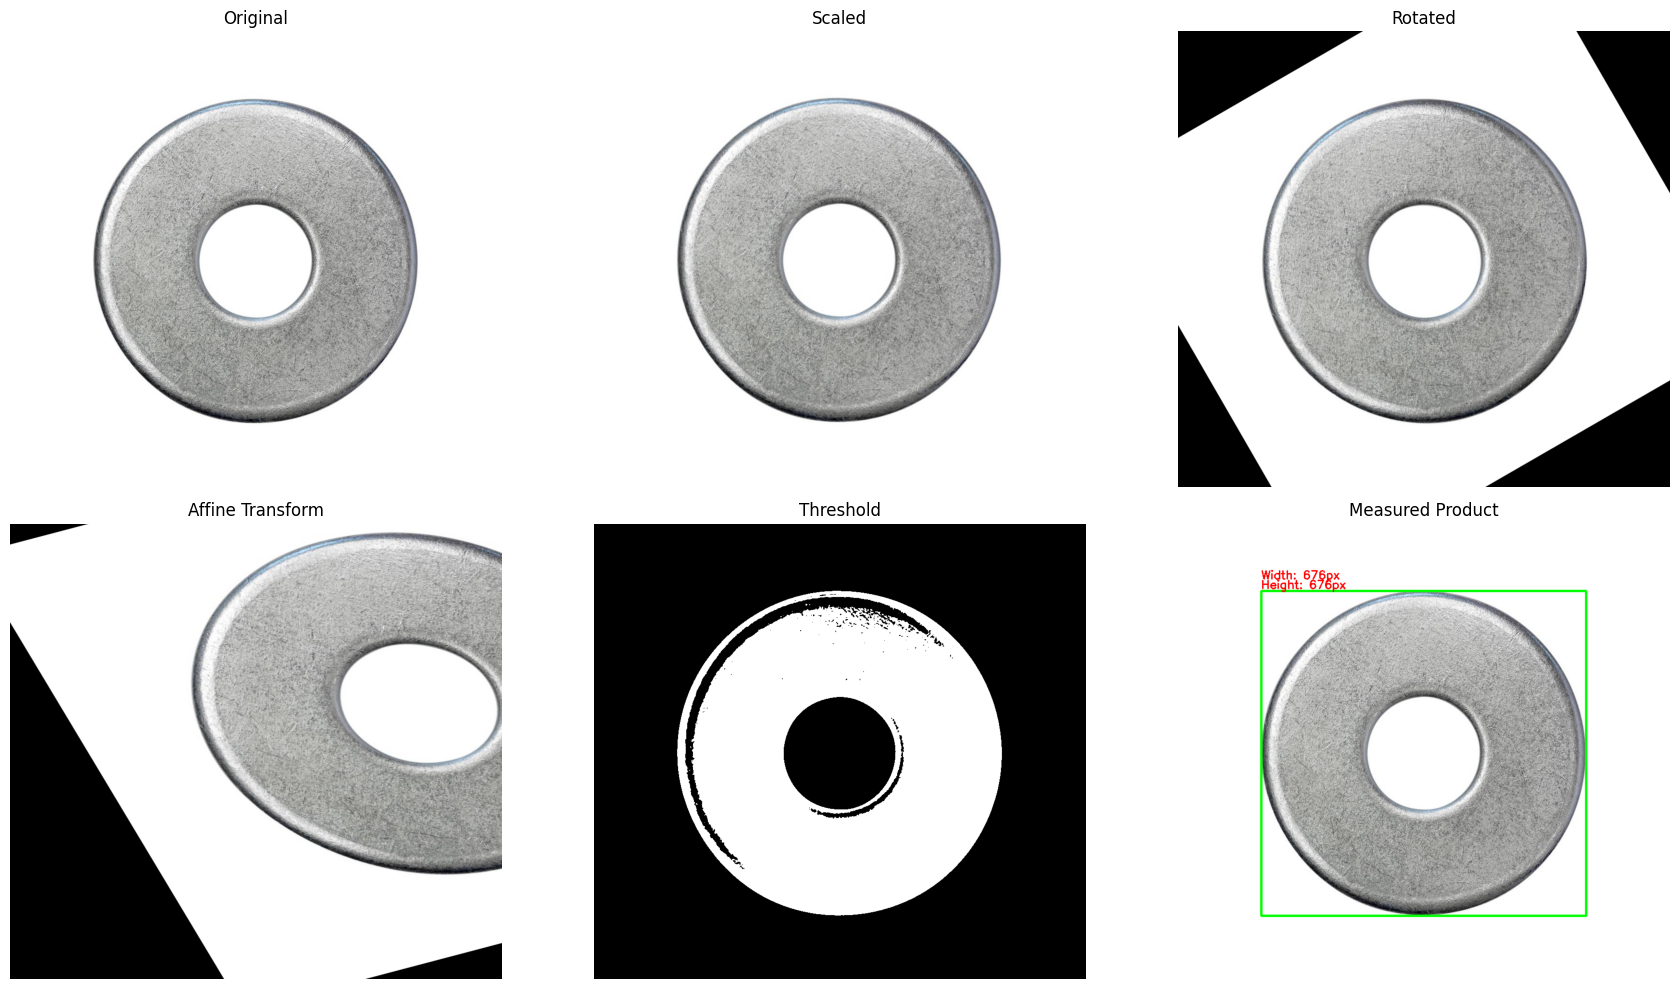

In [1]:
# ==============================================
# PRODUCT DIMENSION MEASUREMENT USING OPENCV
# Scaling, Rotation, Affine Transformation
# Pixel-Based Measurement
# Google Colab
# ==============================================

# Install OpenCV (if needed)
!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Original Image Shape:", image.shape)

# -----------------------------
# Scaling
# -----------------------------
scaled = cv2.resize(rgb, None, fx=1.5, fy=1.5)

# -----------------------------
# Rotation
# -----------------------------
(h, w) = rgb.shape[:2]
center = (w//2, h//2)

rotation_matrix = cv2.getRotationMatrix2D(center, 30, 1)

rotated = cv2.warpAffine(rgb, rotation_matrix, (w, h))

# -----------------------------
# Affine Transformation
# -----------------------------
rows, cols = rgb.shape[:2]

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

affine_matrix = cv2.getAffineTransform(pts1, pts2)

affine = cv2.warpAffine(rgb, affine_matrix, (cols, rows))

# -----------------------------
# Object Measurement
# -----------------------------

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray,(5,5),0)

# Threshold
_, thresh = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = rgb.copy()

largest = max(contours, key=cv2.contourArea)

# Bounding rectangle
x,y,w,h = cv2.boundingRect(largest)

# Draw rectangle
cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),3)

# Put dimensions
cv2.putText(output,
            f"Width: {w}px",
            (x,y-25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,0,0),
            2)

cv2.putText(output,
            f"Height: {h}px",
            (x,y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255,0,0),
            2)

print("\nEstimated Product Dimensions")
print("-----------------------------")
print("Width :", w, "pixels")
print("Height:", h, "pixels")

# -----------------------------
# Display Results
# -----------------------------

plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(scaled)
plt.title("Scaled")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(affine)
plt.title("Affine Transform")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(thresh,cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(output)
plt.title("Measured Product")
plt.axis("off")

plt.tight_layout()
plt.show()